In [50]:
#Install Package
!pip install yfinance
!pip install yahoofinancials


In [51]:
import pandas as pd
import yfinance as yf
import requests
from io import StringIO
from IPython.display import display

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
response.raise_for_status()

tables = pd.read_html(StringIO(response.text))

sp500_table = None
for table in tables:
    cols_lower = [str(c).lower() for c in table.columns]
    if "symbol" in cols_lower:
        sp500_table = table.copy()
        break

if sp500_table is None:
    raise ValueError("No table with a 'Symbol' column found on the page.")

for col in sp500_table.columns:
    if str(col).lower() == "symbol":
        symbol_col = col
        break

sp500_table.rename(columns={symbol_col: "Symbol"}, inplace=True)

sp500_table["Symbol"] = (
    sp500_table["Symbol"]
    .astype(str)
    .str.replace(".", "-", regex=False)
)

tickers = sp500_table["Symbol"].unique().tolist()

print("Number of tickers:", len(tickers))
display(sp500_table.head())

hist = yf.download(tickers=tickers, start='2022-01-01', end='2025-01-01', interval='1d', actions=False)


Number of tickers: 503


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


/tmp/ipykernel_51354/1775929807.py:43: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hist = yf.download(tickers=tickers, start='2022-01-01', end='2025-01-01', interval='1d', actions=False)
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')


In [52]:
hist

Price      Adj Close            Close                                      \
Ticker             Q SNDK           A        AAPL        ABBV        ABNB   
Date                                                                        
2022-01-03       NaN  NaN  151.702133  178.103653  115.847221  172.679993   
2022-01-04       NaN  NaN  146.573669  175.843231  115.624817  170.800003   
2022-01-05       NaN  NaN  144.062744  171.165817  116.232185  162.250000   
2022-01-06       NaN  NaN  144.566879  168.308517  115.684685  159.750000   
2022-01-07       NaN  NaN  140.718094  168.474869  115.385284  166.050003   
...              ...  ...         ...         ...         ...         ...   
2024-12-24       NaN  NaN  134.457260  256.797241  172.530670  134.990005   
2024-12-26       NaN  NaN  134.190521  257.612701  171.763855  135.320007   
2024-12-27       NaN  NaN  133.904022  254.201385  170.623245  133.384995   
2024-12-30       NaN  NaN  132.797546  250.829788  168.888336  131.809998   
2024-12-31       NaN  NaN  132.963806  249.059464  170.326111  131.410004   

Price                                                      ...   Volume  \
Ticker             ABT       ACGL         ACN        ADBE  ...       WY   
Date                                                       ...            
2022-01-03  128.346008  42.362530  383.711975  564.369995  ...  3831100   
2022-01-04  125.327515  42.914051  380.969910  554.000000  ...  3089700   
2022-01-05  124.764435  42.410072  374.260651  514.429993  ...  3737600   
2022-01-06  124.745949  42.657307  356.187469  514.119995  ...  3315200   
2022-01-07  125.133629  42.856995  349.355896  510.700012  ...  3309900   
...                ...        ...         ...         ...  ...      ...   
2024-12-24  112.058296  92.669998  356.539642  447.940002  ...  1780100   
2024-12-26  112.556282  92.930000  355.356537  450.160004  ...  1736500   
2024-12-27  112.282883  92.339996  351.166321  446.480011  ...  2320500   
2024-12-30  110.144440  91.889999  347.528290  445.799988  ...  2914700   
2024-12-31  110.447136  92.349998  346.838165  444.679993  ...  3125200   

Price                                                                        \
Ticker         WYNN      XEL       XOM      XYL       XYZ      YUM      ZBH   
Date                                                                          
2022-01-03  2437800  3501100  24282400   759100   7315700  1251400  1184809   
2022-01-04  2292300  4197000  38584000   925400  14768500   935900  1400800   
2022-01-05  3439900  4166000  34033300  1090200  17546200   977900  1895715   
2022-01-06  2583200  2296000  30668500   703400  16244200   862400  1088813   
2022-01-07  1720400  2673100  23985400   765000   9426000   833700  1690230   
...             ...      ...       ...      ...       ...      ...      ...   
2024-12-24   692800   943900   7807000   379300   2197700   533000   458600   
2024-12-26  1218900  1394900   9652400   575700   2991100  1040900  1277300   
2024-12-27  1086700  2015000  11943900   552400   4140800  1146300   743400   
2024-12-30  2180100  2642900  11080800   586800   5383800  1144600  1532000   
2024-12-31  1612600  2143800  12387800   641600   4989400  1217100   683300   

Price                        
Ticker        ZBRA      ZTS  
Date                         
2022-01-03  272600  2772700  
2022-01-04  346000  4664000  
2022-01-05  403700  4749400  
2022-01-06  338300  3103400  
2022-01-07  432800  2206500  
...            ...      ...  
2024-12-24   88700  1023600  
2024-12-26  140100  2167200  
2024-12-27  287200  1800100  
2024-12-30  211300  1531400  
2024-12-31  327900  1327400  

[753 rows x 2517 columns]

In [53]:
hist = hist.drop('Q', axis=1, level=1)
hist = hist.drop('SNDK', axis=1, level=1)
hist = hist.drop('GEV', axis=1, level=1)
hist = hist.drop('SOLV', axis=1, level=1)
hist = hist.drop('VLTO', axis=1, level=1)
hist = hist.drop('KVUE', axis=1, level=1)
hist = hist.drop('GEHC', axis=1, level=1)
hist = hist.bfill()
hist

Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2022-01-03  151.702133  178.103653  115.847221  172.679993  128.346008   
2022-01-04  146.573669  175.843231  115.624817  170.800003  125.327515   
2022-01-05  144.062744  171.165817  116.232185  162.250000  124.764435   
2022-01-06  144.566879  168.308517  115.684685  159.750000  124.745949   
2022-01-07  140.718094  168.474869  115.385284  166.050003  125.133629   
...                ...         ...         ...         ...         ...   
2024-12-24  134.457260  256.797241  172.530670  134.990005  112.058296   
2024-12-26  134.190521  257.612701  171.763855  135.320007  112.556282   
2024-12-27  133.904022  254.201385  170.623245  133.384995  112.282883   
2024-12-30  132.797546  250.829788  168.888336  131.809998  110.144440   
2024-12-31  132.963806  249.059464  170.326111  131.410004  110.447136   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2022-01-03  42.362530  383.711975  564.369995  164.526459  60.037281  ...   
2022-01-04  42.914051  380.969910  554.000000  163.040466  61.151516  ...   
2022-01-05  42.410072  374.260651  514.429993  160.523575  60.673981  ...   
2022-01-06  42.657307  356.187469  514.119995  161.034409  61.213432  ...   
2022-01-07  42.856995  349.355896  510.700012  156.808624  61.735184  ...   
...               ...         ...         ...         ...        ...  ...   
2024-12-24  92.669998  356.539642  447.940002  213.882034  48.364082  ...   
2024-12-26  92.930000  355.356537  450.160004  213.852631  48.344975  ...   
2024-12-27  92.339996  351.166321  446.480011  212.803284  48.316322  ...   
2024-12-30  91.889999  347.528290  445.799988  208.458755  47.829140  ...   
2024-12-31  92.349998  346.838165  444.679993  208.360687  48.259007  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2022-01-03  3831100  2437800  3501100  24282400   759100   7315700  1251400   
2022-01-04  3089700  2292300  4197000  38584000   925400  14768500   935900   
2022-01-05  3737600  3439900  4166000  34033300  1090200  17546200   977900   
2022-01-06  3315200  2583200  2296000  30668500   703400  16244200   862400   
2022-01-07  3309900  1720400  2673100  23985400   765000   9426000   833700   
...             ...      ...      ...       ...      ...       ...      ...   
2024-12-24  1780100   692800   943900   7807000   379300   2197700   533000   
2024-12-26  1736500  1218900  1394900   9652400   575700   2991100  1040900   
2024-12-27  2320500  1086700  2015000  11943900   552400   4140800  1146300   
2024-12-30  2914700  2180100  2642900  11080800   586800   5383800  1144600   
2024-12-31  3125200  1612600  2143800  12387800   641600   4989400  1217100   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2022-01-03  1184809  272600  2772700  
2022-01-04  1400800  346000  4664000  
2022-01-05  1895715  403700  4749400  
2022-01-06  1088813  338300  3103400  
2022-01-07  1690230  432800  2206500  
...             ...     ...      ...  
2024-12-24   458600   88700  1023600  
2024-12-26  1277300  140100  2167200  
2024-12-27   743400  287200  1800100  
2024-12-30  1532000  211300  1531400  
2024-12-31   683300  327900  1327400  

[753 rows x 2480 columns]

In [54]:
import numpy as np

data = hist['Close']

daily_returns = data.pct_change()

daily_returns

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.033806,-0.012692,-0.001920,-0.010887,-0.023518,0.013019,-0.007146,-0.018374,-0.009032,0.018559,...,0.012818,-0.003190,0.006329,0.037614,0.010608,-0.046943,0.005347,0.010145,0.006337,-0.038072
2022-01-05,-0.017131,-0.026600,0.005253,-0.050059,-0.004493,-0.011744,-0.017611,-0.071426,-0.015437,-0.007809,...,-0.024824,-0.037033,0.009799,0.012437,-0.013629,-0.082134,-0.012677,-0.003297,-0.050068,-0.038024
2022-01-06,0.003499,-0.016693,-0.004710,-0.015408,-0.000148,0.005830,-0.048290,-0.000603,0.003182,0.008891,...,0.007986,0.004629,-0.007821,0.023521,-0.001373,0.008154,0.010331,-0.008307,-0.005410,0.003971
2022-01-07,-0.026623,0.000988,-0.002588,0.039437,0.003108,0.004681,-0.019180,-0.006652,-0.026241,0.008523,...,-0.001238,-0.001063,0.008759,0.008197,-0.007992,-0.021568,-0.011466,-0.006050,-0.043771,-0.029114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011144,0.011478,0.009025,0.003494,0.003937,0.006298,0.007972,0.002686,0.014891,0.004364,...,0.006410,0.007604,0.007236,0.000941,0.005446,0.020047,0.008516,0.004494,0.012262,0.002557
2024-12-26,-0.001984,0.003176,-0.004445,0.002445,0.004444,0.002806,-0.003318,0.004956,-0.000137,-0.000395,...,-0.003185,0.005970,-0.000440,0.000846,0.002708,0.004392,0.007407,-0.000466,0.003566,0.004979
2024-12-27,-0.002135,-0.013242,-0.006641,-0.014300,-0.002429,-0.006349,-0.011792,-0.008175,-0.004907,-0.000593,...,-0.006390,-0.007054,-0.000587,-0.000094,-0.007934,-0.027438,-0.005662,-0.003543,-0.019604,-0.005558


In [55]:
def fetch_data(tickers, index='^GSPC', start='2022-01-01', end='2025-01-01', interval='1d'):
    all_tickers = tickers + [index]
    df = yf.download(all_tickers, start=start, end=end, interval=interval)['Close']
    return df


def calculate_ratios(returns, benchmark_returns, risk_free_rate=0.04/252):
    excess = returns - risk_free_rate
    downside = excess[excess < 0]

    beta = np.cov(returns, benchmark_returns)[0,1] / np.var(benchmark_returns)
    return beta


def build_screener(tickers, index='^GSPC', start='2022-01-01',end='2025-01-01', risk_free_rate=0.04/252):
    df = fetch_data(tickers, index=index, start=start, end=end)
    benchmark = df[index].pct_change().dropna()
    results = []

    for ticker in tickers:
        ret = df[ticker].pct_change().dropna()
        aligned = pd.concat([ret, benchmark], axis=1, join='inner').dropna()
        beta = calculate_ratios(aligned[ticker], aligned[index], risk_free_rate)
        results.append({'Ticker': ticker, 'Beta': beta})

    return pd.DataFrame(results).sort_values('Beta', ascending=False)

In [56]:
df = build_screener(tickers, index='^GSPC', start ='2022-01-01', end='2025-01-01')
df

/tmp/ipykernel_51354/1603783966.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(all_tickers, start=start, end=end, interval=interval)['Close']
[*********************100%***********************]  504 of 504 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')
/tmp/ipykernel_51354/1603783966.py:21: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = df[ticker].pct_change().dropna()
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/loc

,Ticker,Beta
88,CVNA,3.298454
117,COIN,2.964902
67,XYZ,2.548173
344,NVDA,2.271536
40,APP,2.264945
...,...,...
414,SJM,0.196850
83,CPB,0.133844
218,GIS,0.133426
386,Q,NaN


In [57]:
annual_volatility = daily_returns.std() * np.sqrt(252)
annual_volatility

,0
Ticker,
A,0.296259
AAPL,0.270935
ABBV,0.219958
ABNB,0.467875
ABT,0.217839
...,...
XYZ,0.653825
YUM,0.191335
ZBH,0.245157


In [58]:
mean_daily_return = daily_returns.mean()

volatility_df = annual_volatility.reset_index()
volatility_df.columns = ['Ticker', 'Annual Volatility']

daily_return_df = mean_daily_return.reset_index()
daily_return_df.columns = ['Ticker', 'Daily Return']

merged_df = df.merge(volatility_df, on='Ticker').merge(daily_return_df, on='Ticker')

merged_df.head()

,Ticker,Beta,Annual Volatility,Daily Return
0,CVNA,3.298454,1.341039,0.003219
1,COIN,2.964902,0.953848,0.001768
2,XYZ,2.548173,0.653825,-0.000034
3,NVDA,2.271536,0.552710,0.002588
4,APP,2.264945,0.788374,0.002802


In [62]:
def classify_stock(row):
    beta = row["Beta"]
    volatility = row["Annual Volatility"]
    return_daily = row["Daily Return"]

    if beta < 0.9 and return_daily > 0.01:
        return "Safe, High profit"

    elif beta < 0.9 and return_daily > 0:
        return "Low Risk, Low profit"

    elif beta < 0.9:
        return "Low Risk"

    elif 0.9 <= beta <= 1.1:
        return "Moderate"

    else:
        return "High Risk"

merged_df["Portfolio"] = merged_df.apply(classify_stock, axis=1)
merged_df

,Ticker,Beta,Annual Volatility,Daily Return,Portfolio
0,CVNA,3.298454,1.341039,0.003219,High Risk
1,COIN,2.964902,0.953848,0.001768,High Risk
2,XYZ,2.548173,0.653825,-0.000034,High Risk
3,NVDA,2.271536,0.552710,0.002588,High Risk
4,APP,2.264945,0.788374,0.002802,High Risk
...,...,...,...,...,...
491,LMT,0.244190,0.209530,0.000611,"Low Risk, Low profit"
492,HRL,0.236922,0.232603,-0.000376,Low Risk
493,SJM,0.196850,0.219994,-0.000065,Low Risk
494,CPB,0.133844,0.223119,0.000168,"Low Risk, Low profit"


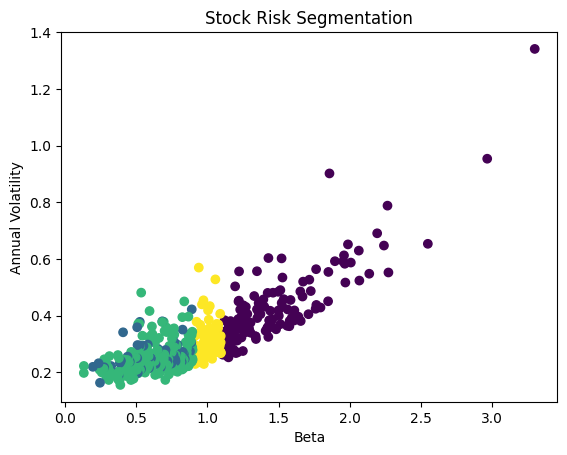

In [64]:
import matplotlib.pyplot as plt

plt.scatter(merged_df["Beta"], merged_df["Annual Volatility"],
            c=merged_df["Portfolio"].astype("category").cat.codes)

plt.xlabel("Beta")
plt.ylabel("Annual Volatility")
plt.title("Stock Risk Segmentation")
plt.show()